# Imports

In [27]:
import numpy as np
import networkx as nx
import pandas as pd
import random
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# Helper Functions

## Graph and Covariate Generation

In [28]:
def _block_labels(num_blocks, total_nodes):
    proportions = np.random.dirichlet(np.ones(num_blocks))
    sizes = np.round(proportions * total_nodes).astype(int)

    diff = total_nodes - sizes.sum()
    sizes[0] += diff

    labels = np.concatenate([
        np.full(size, b) for b, size in enumerate(sizes)
    ])

    np.random.shuffle(labels)
    return labels


def _probability_matrix(num_blocks, p_in, p_out):
    P = np.full((num_blocks, num_blocks), p_out)
    np.fill_diagonal(P, p_in)
    return P


def _adjacency_matrix(labels, P):
    n = len(labels)
    A = np.zeros((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            if np.random.rand() < P[labels[i], labels[j]]:
                A[i, j] = A[j, i] = 1

    return A


def _sample_opinions(blocks, num_blocks, num_opinions, correlation):
    dominant = np.random.randint(num_opinions, size=num_blocks)
    opinions = np.empty(len(blocks), dtype=int)

    for i, b in enumerate(blocks):
        probs = np.full(num_opinions, (1 - correlation) / (num_opinions - 1))
        probs[dominant[b]] = correlation
        opinions[i] = np.random.choice(num_opinions, p=probs)

    return opinions


def generate_sbm(
    seed,
    num_blocks,
    total_nodes,
    p_in,
    p_out,
    num_opinions,
    opinion_correlation,
):
    np.random.seed(seed)
    random.seed(seed)

    labels = _block_labels(num_blocks, total_nodes)
    P = _probability_matrix(num_blocks, p_in, p_out)
    A = _adjacency_matrix(labels, P)

    G = nx.from_numpy_array(A)

    df = pd.DataFrame({
        "node_id": np.arange(len(labels)),
        "block": labels,
    })

    df["degree"] = [d for _, d in G.degree()]
    df["opinion"] = _sample_opinions(
        labels, num_blocks, num_opinions, opinion_correlation
    )

    return G, labels, df


## RDS Simulation

In [29]:
def _init_seeds(G, num_seeds):
    seeds = random.sample(list(G.nodes()), num_seeds)
    queue = [(s, 0) for s in seeds]
    sampled = set(seeds)

    records = [
        {"node_id": s, "recruiter": None, "wave": 0}
        for s in seeds
    ]

    return seeds, queue, sampled, records


def _recruit_neighbors(G, node, sampled, max_recruits):
    neighbors = list(G.neighbors(node))
    random.shuffle(neighbors)

    recruits = []
    for nb in neighbors:
        if nb not in sampled:
            recruits.append(nb)
            if len(recruits) >= max_recruits:
                break

    return recruits


def _add_recruits(
    recruits,
    recruiter,
    wave,
    sampled,
    queue,
    records,
    referrer_map,
):
    for nb in recruits:
        sampled.add(nb)

        records.append({
            "node_id": nb,
            "recruiter": recruiter,
            "wave": wave + 1,
        })

        referrer_map[recruiter].append(nb)
        queue.append((nb, wave + 1))


def rds_with_tracking(G, num_seeds, sample_size=50, max_recruits=2):
    _, queue, sampled, records = _init_seeds(G, num_seeds)
    referrer_to_recruits = defaultdict(list)

    while queue and len(sampled) < sample_size:
        node, wave = queue.pop(0)

        recruits = _recruit_neighbors(G, node, sampled, max_recruits)

        remaining = sample_size - len(sampled)
        recruits = recruits[:remaining]

        _add_recruits(
            recruits,
            node,
            wave,
            sampled,
            queue,
            records,
            referrer_to_recruits,
        )

    return pd.DataFrame(records), referrer_to_recruits


def attach_covariates_after_rds(rds_df, covariates):
    return rds_df.merge(
        covariates[["node_id", "opinion", "degree", "block"]],
        on="node_id",
        how="left",
    )

## Sampling Statistics

In [30]:
def vh_estimator(rds_df):
    weights = 1 / rds_df["degree"]
    
    weighted_counts = (
        rds_df
        .assign(weight=weights)
        .groupby("opinion")["weight"]
        .sum()
    )

    return (weighted_counts / weighted_counts.sum()).sort_index()

def get_distribution(series):
    return series.value_counts(normalize=True).sort_index()


def total_variation(p, q):
    idx = sorted(set(p.index).union(q.index))
    p = p.reindex(idx, fill_value=0)
    q = q.reindex(idx, fill_value=0)
    return 0.5 * np.abs(p - q).sum()


def kl_divergence(p_true, p_est, eps=1e-12):
    idx = sorted(set(p_true.index).union(p_est.index))
    p = p_true.reindex(idx, fill_value=0).values.astype(float) + eps
    q = p_est.reindex(idx, fill_value=0).values.astype(float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(p * np.log(p / q)))

## Adjustments for Homophily and Small Size

In [31]:
def invert_referrals(referrer_to_recruits):
    return {
        recruit: referrer
        for referrer, recruits in referrer_to_recruits.items()
        for recruit in recruits
    }


def vh_with_homophily_adjustment(rds_df, covariates_df, recruiter_map, alpha, return_modified_df=False):
    weights = []
    alphas = []
    
    for _, row in rds_df.iterrows():
        node = row["node_id"]
        base_weight = 1 / row["degree"]
        
        recruiter = recruiter_map.get(node, None)
        
        if recruiter is None:
            weights.append(base_weight)  # seed
            alphas.append(1.0)
            continue
        
        # compare blocks
        if covariates_df.loc[node, "block"] == covariates_df.loc[recruiter, "block"]:
            weights.append(alpha * base_weight)
            alphas.append(alpha)
        else:
            weights.append(base_weight)
            alphas.append(1.0)
    
    rds_df = rds_df.copy()
    rds_df["weight"] = weights
    rds_df["alpha"] = alphas
    
    weighted_counts = (
        rds_df
        .groupby("opinion")["weight"]
        .sum()
    )
    
    if return_modified_df:
        return (weighted_counts / weighted_counts.sum()).sort_index(), rds_df
    else:
        return (weighted_counts / weighted_counts.sum()).sort_index()

def compute_alpha(correlation, SBM_p):
    k = 1 / (1 - SBM_p)
    return 1 / (1 + (k - 1) * correlation)

In [32]:
def single_experiment(
    seed,
    num_blocks,
    total_nodes,
    p_in,
    p_out,
    num_opinions,
    opinion_correlation,
    RDS_num_seeds,
    RDS_sample_size,
    max_recruits
):
    G, labels, graph_covariates = generate_sbm(
        seed=seed,
        num_blocks=num_blocks,
        total_nodes=total_nodes,
        p_in=p_in,
        p_out=p_out,
        num_opinions=num_opinions,
        opinion_correlation=opinion_correlation,
    )
    
    rds_df, referrer_to_recruits = rds_with_tracking(G, num_seeds=RDS_num_seeds, sample_size=RDS_sample_size, max_recruits=max_recruits)
    rds_df = attach_covariates_after_rds(rds_df, graph_covariates)
    
    recruiter_map = invert_referrals(referrer_to_recruits)
    
    sample_dist = get_distribution(rds_df["opinion"])
    vh_dist = vh_estimator(rds_df)
    
    found_alpha = compute_alpha(correlation=opinion_correlation, SBM_p=p_in)  # Example values
    adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=found_alpha)
    
    pop_dist = get_distribution(graph_covariates["opinion"])
    
    return {
        "sample_dist": sample_dist,
        "vh_dist": vh_dist,
        "adj_dist": adj_dist,
        "pop_dist": pop_dist,
        "found_alpha": found_alpha,
        "rds_df": rds_df,
        "graph_covariates": graph_covariates,
        "recruiter_map": recruiter_map
    }

# Experimental Testing

## Single Sample

In [33]:
result = single_experiment(
    seed=12,
    num_blocks=7,
    total_nodes=120,
    p_in=0.5,
    p_out=0.02,
    num_opinions=4,
    opinion_correlation=0.90,
    RDS_num_seeds=2,
    RDS_sample_size=30,
    max_recruits=2
)

sample_dist = result["sample_dist"]
vh_dist = result["vh_dist"]
adj_dist = result["adj_dist"]
pop_dist = result["pop_dist"]
found_alpha = result["found_alpha"]
rds_df = result["rds_df"]
graph_covariates = result["graph_covariates"]
recruiter_map = result["recruiter_map"]

In [34]:
print(f"Sample Distribution: {sample_dist}")
print(f"VH Distribution: {vh_dist}")
print(f"Adjusted Distribution: {adj_dist}")
print(f"Populatoin Distribution: {pop_dist}")

df_KL = pd.DataFrame({
    "Sample Frequency vs. Population": kl_divergence(sample_dist, pop_dist),
    "VH vs. Population": kl_divergence(vh_dist, pop_dist),
    "Adjusted vs. Population": kl_divergence(adj_dist, pop_dist),
},
index=["KL Divergence"]
)

print(df_KL.T.to_latex())

Sample Distribution: opinion
0    0.633333
1    0.200000
2    0.033333
3    0.133333
Name: proportion, dtype: float64
VH Distribution: opinion
0    0.517630
1    0.242250
2    0.018317
3    0.221803
Name: weight, dtype: float64
Adjusted Distribution: opinion
0    0.412952
1    0.271898
2    0.014024
3    0.301126
Name: weight, dtype: float64
Populatoin Distribution: opinion
0    0.308333
1    0.216667
2    0.025000
3    0.450000
Name: proportion, dtype: float64
\begin{tabular}{lr}
\toprule
 & KL Divergence \\
\midrule
Sample Frequency vs. Population & 0.287278 \\
VH vs. Population & 0.132597 \\
Adjusted vs. Population & 0.053308 \\
\bottomrule
\end{tabular}



Optimal alpha: 0.28 with KL divergence 0.0266


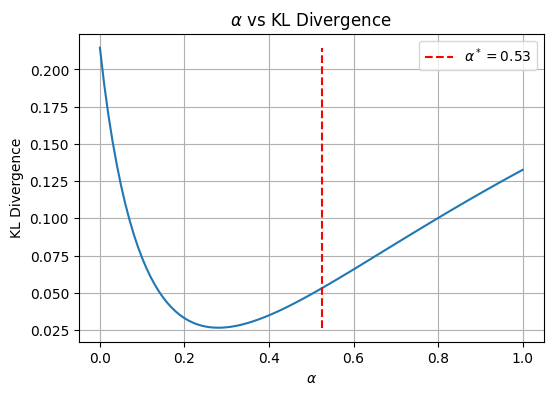

In [35]:
alphas = np.arange(0, 1.01, 0.01)
kl_vals = []

for alpha in alphas:
    adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=alpha)
    kl = kl_divergence(adj_dist, pop_dist)
    kl_vals.append(kl)

true_best_alpha = np.argmin(kl_vals)
print(f"Optimal alpha: {alphas[true_best_alpha]:.2f} with KL divergence {kl_vals[true_best_alpha]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(alphas, kl_vals)
plt.xlabel("$\\alpha$")
plt.ylabel("KL Divergence")
plt.title("$\\alpha$ vs KL Divergence")
plt.vlines(x=found_alpha, ymin=min(kl_vals), ymax=max(kl_vals), colors='r', linestyles='dashed', label=f'$\\alpha^*={found_alpha:.2f}$')
plt.grid(True)
plt.legend()
plt.savefig("../img/single_trial_alpha_vs_kl.pdf")
plt.show()

## Distribution of Alpha Estimates vs. True Optimal Alpha

In [36]:
alpha_best_minus_found = []
kl_differences = []

for i in range(100):
    result = single_experiment(
        seed=i,
        num_blocks=7,
        total_nodes=120,
        p_in=0.5,
        p_out=0.02,
        num_opinions=4,
        opinion_correlation=0.90,
        RDS_num_seeds=2,
        RDS_sample_size=30,
        max_recruits=2
    )

    sample_dist = result["sample_dist"]
    vh_dist = result["vh_dist"]
    adj_dist = result["adj_dist"]
    pop_dist = result["pop_dist"]
    found_alpha = result["found_alpha"]
    rds_df = result["rds_df"]
    graph_covariates = result["graph_covariates"]
    recruiter_map = result["recruiter_map"]

    kl_using_found_alpha = kl_divergence(adj_dist, pop_dist)

    alphas = np.arange(0, 1.01, 0.01)
    kl_vals = []

    for alpha in alphas:
        adj_dist = vh_with_homophily_adjustment(rds_df, graph_covariates, recruiter_map, alpha=alpha)
        kl = kl_divergence(adj_dist, pop_dist)
        kl_vals.append(kl)
    
    best_kl = min(kl_vals)

    true_best_alpha = alphas[np.argmin(kl_vals)]
    alpha_best_minus_found.append(true_best_alpha - found_alpha)

    kl_difference = kl_vals[-1] - kl_using_found_alpha
    kl_differences.append(kl_difference)

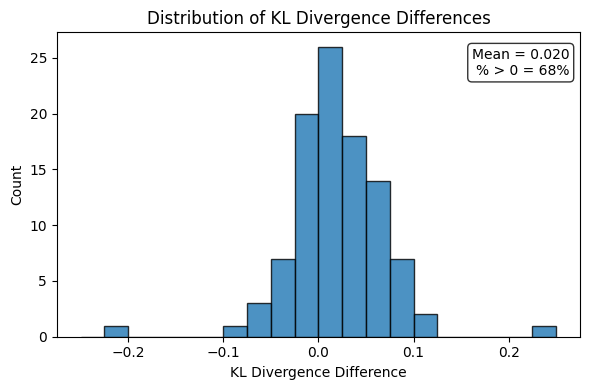

68
0.01983011994819448


In [37]:

bins = np.arange(-0.25, 0.275, 0.025)

mean_val = np.mean(kl_differences)
num_positive = sum(x > 0 for x in kl_differences)

plt.figure(figsize=(6, 4))

plt.hist(
    kl_differences,
    bins=bins,
    edgecolor='black',
    alpha=0.8
)


plt.xlabel("KL Divergence Difference")
plt.ylabel("Count")
plt.title("Distribution of KL Divergence Differences")

plt.text(
    0.98, 0.95,
    f"Mean = {mean_val:.3f}\n% > 0 = {num_positive/len(kl_differences):.0%}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.savefig("../img/kl_difference_histogram.pdf")
plt.show()

print(num_positive)
print(mean_val)

In [38]:
print(found_alpha)

0.5263157894736842


# Anti-AI Data

## Data Cleaning

In [39]:
survey_data = pd.read_csv("../data/form_responses.csv")

survey_data = survey_data[survey_data["Do you consider yourself anti-AI? "] == "Yes"]

map_sentiment = {
    "I have concerns about its impact on jobs and economic inequality.": "jobs_economy",
    "I have concerns about about its impact on the environment.": "environment",
    "I have concerns about its impact on interpersonal relationships.": "relationships",
    "I don't think the technology is trustworthy and secure.": "trust_security",
}

survey_data["opinion"] = survey_data["Why are you anti-AI? Please choose the response that most closely reflects your opinion. "].map(map_sentiment)

## Distribution of Sentiment

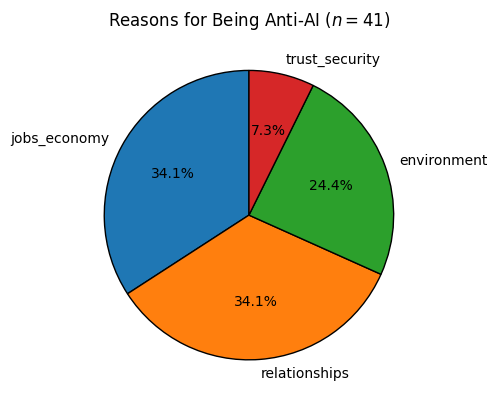

In [40]:
counts = survey_data["opinion"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title(f"Reasons for Being Anti-AI ($n = {len(survey_data)}$)")
plt.tight_layout()
plt.savefig("../img/anti_ai_reasons_pie_chart.pdf")
plt.show()

## Covariate Distribution

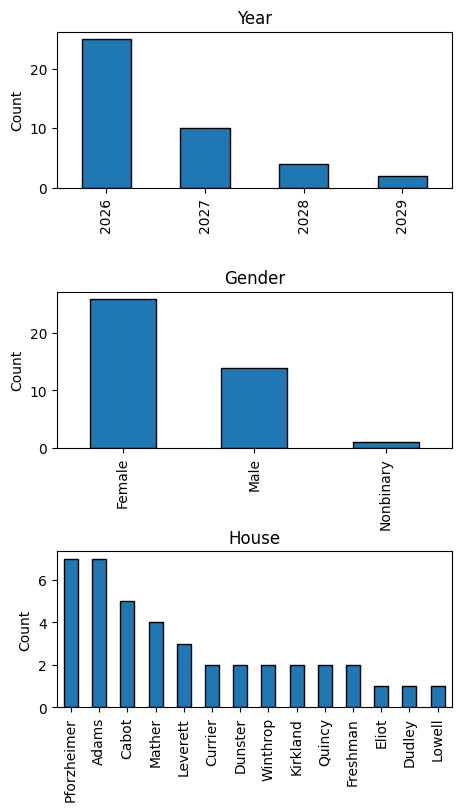

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(4.5, 8))

survey_data["Year"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black"
)
axes[0].set_title("Year")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

survey_data["Gender_long"] = survey_data["Gender"].replace({
    "W": "Female",
    "M": "Male",
    "N": "Nonbinary"
})

survey_data["Gender_long"].value_counts().plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black"
)
axes[1].set_title("Gender")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

survey_data["House"].value_counts().plot(
    kind="bar",
    ax=axes[2],
    edgecolor="black"
)
axes[2].set_title("House")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.tight_layout(pad=0.3, h_pad=0)
plt.savefig("../img/survey_demographics.pdf")
plt.show()

## Distribution of political affiliation

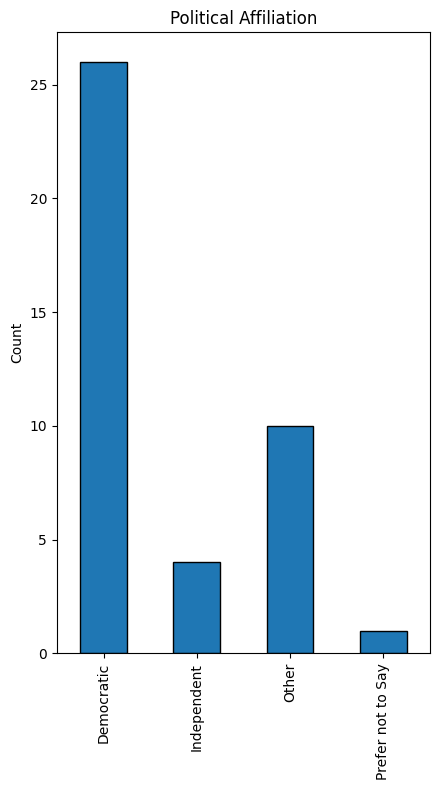

In [42]:
plt.figure(figsize=(4.5, 8))

counts = survey_data["What political party do you most closely identify with?"] \
    .value_counts().sort_index()

counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Political Affiliation")
plt.xlabel("")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

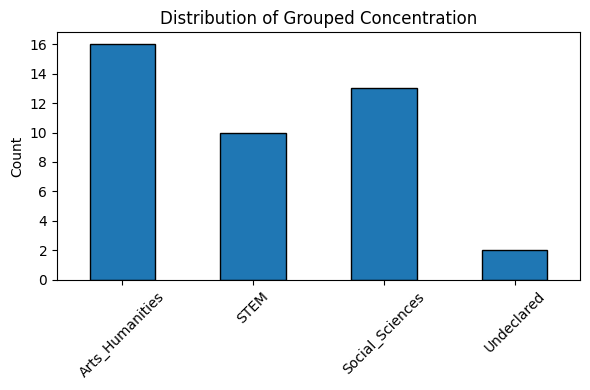

In [43]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(6, 4))

survey_data["block"] = survey_data["Grouped_Concentration"].replace({
    "STEM_nontech": "STEM",
    "STEM_tech": "STEM",
})


ax = survey_data["block"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Grouped Concentration")
plt.xlabel("")
plt.xticks(rotation=45)
plt.ylabel("Count")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("../img/grouped_concentration_distribution.pdf")
plt.show()

## Graphing RDS Network

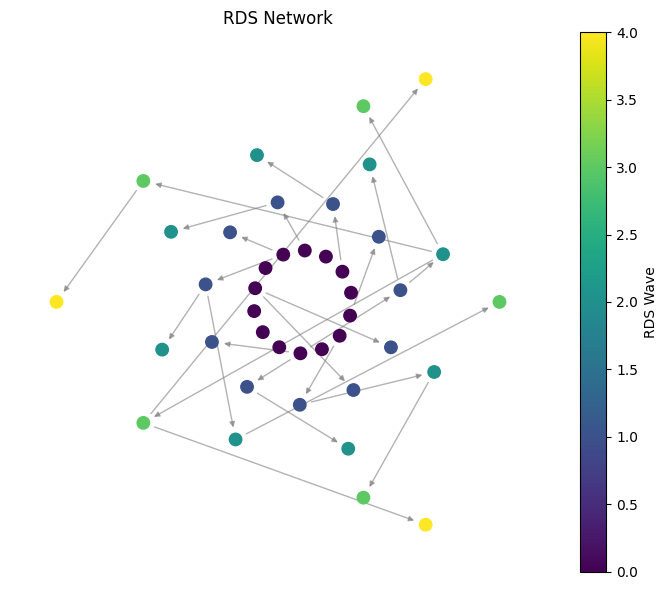

In [44]:
rds_G = nx.DiGraph()

survey_data["Referred by"] = (
    survey_data["Referred by"]
    .replace(["N/A", "Seed"], pd.NA)
)

for _, row in survey_data.iterrows():
    name = row["Name"]
    ref = row["Referred by"]

    rds_G.add_node(name)

    if pd.notna(ref):
        rds_G.add_edge(ref, name)

all_referred = set(survey_data["Referred by"].dropna())
all_names = set(survey_data["Name"])

seeds = survey_data.loc[
    survey_data["Referred by"].isna() | (survey_data["Referred by"] == "Seed"), "Name"
].tolist()

# compute wave of each node
wave = {n: None for n in rds_G.nodes()}

queue = []

for s in seeds:
    if s in rds_G:
        wave[s] = 0
        queue.append(s)

while queue:
    current = queue.pop(0)
    for neighbor in rds_G.successors(current):
        if wave[neighbor] is None:
            wave[neighbor] = wave[current] + 1
            queue.append(neighbor)

waves = [wave[n] if wave[n] is not None else -1 for n in rds_G.nodes()]

# plotting
pos = {}
layers = defaultdict(list)

for node, w in wave.items():
    if w is not None:
        layers[w].append(node)

plt.figure(figsize=(7, 6))

pos = nx.shell_layout(rds_G, nlist=[layers[w] for w in sorted(layers)])

nodes = nx.draw_networkx_nodes(
    rds_G,
    pos,
    node_size=80,
    node_color=[wave[n] if wave[n] is not None else -1 for n in rds_G.nodes()],
    cmap=plt.cm.viridis
)

nx.draw_networkx_edges(
    rds_G,
    pos,
    edge_color="gray",
    arrowsize=8,
    alpha=0.6
)

plt.colorbar(nodes, label="RDS Wave")
plt.title("RDS Network")
plt.axis("off")
plt.tight_layout()
plt.savefig("../img/RDS_network.pdf")
plt.show()

## Compute $p_{in}$ and $\rho$

In [45]:
survey_data["community"] = survey_data["block"]

name_to_comm = dict(zip(survey_data["Name"], survey_data["community"]))

same = 0
different = 0

for u, v in rds_G.edges():
    cu = name_to_comm.get(u)
    cv = name_to_comm.get(v)

    if cu is None or cv is None:
        continue

    if cu == cv:
        same += 1
    else:
        different += 1

counts = Counter(survey_data["community"])
N = len(survey_data)

p_in = same / (same + different)
p_out = different / (same + different)

print("p_in:", p_in)
print("p_out:", p_out)
print("ratio p_in/p_out:", p_in / (p_out + 1e-9))

p_in: 0.5555555555555556
p_out: 0.4444444444444444
ratio p_in/p_out: 1.2499999971875


In [46]:
dominant_opinion = (
    survey_data
    .groupby("community")["opinion"]
    .agg(lambda x: x.value_counts().idxmax())
)

community_to_dominant = dominant_opinion.to_dict()

survey_data["community_dominant_opinion"] = survey_data["community"].map(community_to_dominant)

def dominant_with_fraction(x):
    counts = x.value_counts()
    return pd.Series({
        "dominant": counts.idxmax(),
        "fraction": counts.max() / counts.sum()
    })

community_stats = (
    survey_data
    .groupby("community")["opinion"]
    .apply(dominant_with_fraction)
    .unstack()
)

print(community_stats)

survey_data["matches_dominant"] = (
    survey_data["opinion"] == survey_data["community_dominant_opinion"]
)

rho_empirical = survey_data["matches_dominant"].mean()

print("\nEstimated rho:", rho_empirical)

                      dominant  fraction
community                               
Arts_Humanities  relationships    0.4375
STEM               environment       0.5
Social_Sciences  relationships  0.384615
Undeclared        jobs_economy       1.0

Estimated rho: 0.4634146341463415


## Application of Proposed Estimator to Real Data

alpha* = 0.633


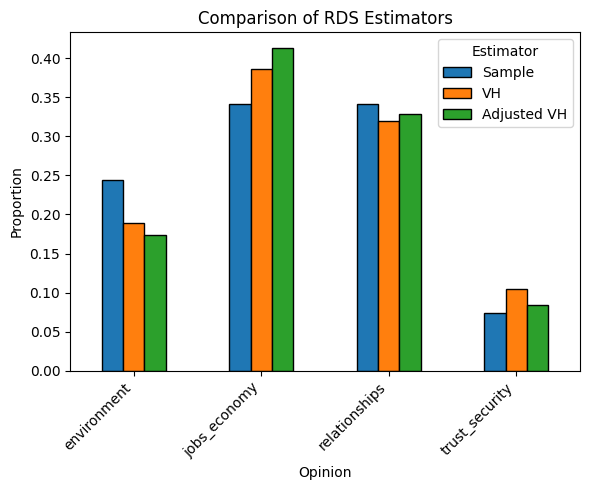

In [47]:
alpha_survey = compute_alpha(correlation=rho_empirical, SBM_p=p_in)
print(f"alpha* = {alpha_survey:.3f}")

degree_col = "To the best of your knowledge, what is the number of known anti-AI Harvard students you've communicated with in the last week? "

survey_rds_df = (
    survey_data.rename(columns={"Name": "node_id"})
    [["node_id", "opinion", "block", "community", "House", degree_col]]
    .assign(
        degree=lambda df: df[degree_col]
    )
    .drop(columns=[degree_col])
)

survey_recruiter_map = {v: u for u, v in rds_G.edges()}
survey_recruiter_map.update({n: None for n in rds_G.nodes() if n not in survey_recruiter_map})

sample_survey_dist = get_distribution(survey_rds_df["opinion"])
vh_survey_dist = vh_estimator(survey_rds_df)

adj_survey_dist, modified_rds_df = vh_with_homophily_adjustment(
    survey_rds_df,
    survey_rds_df.set_index("node_id")[["community", "block"]],
    survey_recruiter_map,
    alpha=alpha_survey,
    return_modified_df=True
)

plot_df = pd.DataFrame({
    "Sample": sample_survey_dist,
    "VH": vh_survey_dist,
    "Adjusted VH": adj_survey_dist
})

plot_df = plot_df.sort_index()

ax = plot_df.plot(
    kind="bar",
    figsize=(6, 5),
    edgecolor="black"
)

ax.set_title("Comparison of RDS Estimators")
ax.set_xlabel("Opinion")
ax.set_ylabel("Proportion")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Estimator")
plt.tight_layout()

plt.savefig("../img/survey_estimators_grouped.pdf")
plt.show()

## Check Robustness With Distribution by House

In [48]:
mapping = {
    "Mather": "east",
    "Dunster": "east",
    "Leverett": "east",
    "Quincy": "central",
    "Adams": "central",
    "Lowell": "central",
    "Kirkland": "west",
    "Eliot": "west",
    "Winthrop": "west",
    "Cabot": "quad",
    "Currier": "quad",
    "Pforzheimer": "quad",
    "Dudley": "quad",
}

# Build the neighborhood-augmented dataframe FIRST, so 'house_neighborhood'
# exists before anything tries to group on it.
df = modified_rds_df.copy()
df["house_neighborhood"] = df["House"].map(mapping)
df = df.dropna(subset=["house_neighborhood", "opinion"])
df["vh_weight"] = 1 / df["degree"].clip(lower=1)


def build_dist(df, weight_col=None):
    grouped = df.groupby(["house_neighborhood", "opinion"])

    if weight_col is None:
        dist = grouped.size().unstack(fill_value=0)
    else:
        dist = grouped[weight_col].sum().unstack(fill_value=0)

    return dist.div(dist.sum(axis=1), axis=0)


def plot_dist(dist, title, ylabel, path):
    ax = dist.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
        edgecolor="black",
    )

    ax.set_title(title)
    ax.set_xlabel("Neighborhood")
    ax.set_ylabel(ylabel)
    ax.legend(title="Opinion", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(path)
    plt.show()


def l2_dispersion(dist, global_dist):
    return ((dist - global_dist) ** 2).sum(axis=1)


# group on `df` (which has 'house_neighborhood'), not survey_rds_df
neighborhood_counts = (
    df.groupby("house_neighborhood")
    .size()
    .rename("n")
)
print(neighborhood_counts)

# unweighted
unweighted = build_dist(df)
# plot_dist(
#     unweighted,
#     "Opinion Distribution by Housing Neighborhood",
#     "Proportion",
#     "../img/opinion_by_neighborhood.pdf"
# )

# VH
vh_dist = build_dist(df, weight_col="vh_weight")
# plot_dist(
#     vh_dist,
#     "VH-Weighted Opinion Distribution by Housing Neighborhood",
#     "Weighted Proportion",
#     "../img/opinion_by_neighborhood_vh.pdf"
# )

# alpha-weighted
df_w = df.dropna(subset=["alpha"])
weighted = build_dist(df_w, weight_col="alpha")
# plot_dist(
#     weighted,
#     "Alpha-Weighted Opinion Distribution by Housing Neighborhood",
#     "Weighted Proportion",
#     "../img/opinion_by_neighborhood_weighted.pdf"
# )

# dispersion measurements
global_unweighted = unweighted.mean(axis=0)
global_weighted = weighted.mean(axis=0)
global_vh = vh_dist.mean(axis=0)

print(f"Unweighted dispersion: {l2_dispersion(unweighted, global_unweighted).mean():.4f}")
print(f"VH dispersion: {l2_dispersion(vh_dist, global_vh).mean():.4f}")
print(f"Weighted dispersion: {l2_dispersion(weighted, global_weighted).mean():.4f}")

house_neighborhood
central    10
east        9
quad       15
west        5
Name: n, dtype: int64
Unweighted dispersion: 0.0364
VH dispersion: 0.0723
Weighted dispersion: 0.0326


/var/folders/f3/0njh09d15914rnlvp5rvn4b80000gn/T/ipykernel_44503/2347521497.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


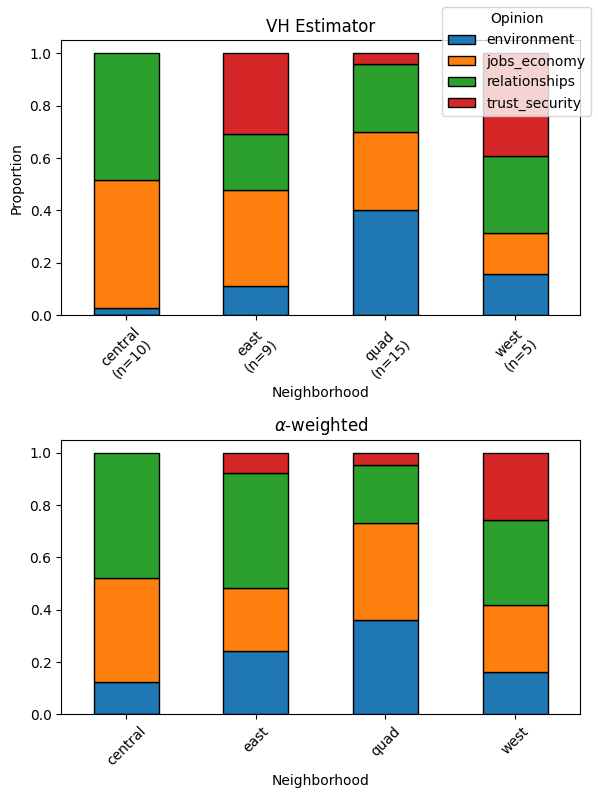

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharey=True)

vh_dist.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    edgecolor="black"
)
axes[0].set_title("VH Estimator")
axes[0].set_xlabel("Neighborhood")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=45)
for ax in axes:
    ax.set_xticklabels([
        f"{label}\n(n={neighborhood_counts[label]})"
        for label in vh_dist.index
    ])

weighted.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    edgecolor="black"
)
axes[1].set_title(r"$\alpha$-weighted")
axes[1].set_xlabel("Neighborhood")
axes[1].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Opinion", loc="upper right")

plt.tight_layout()
plt.savefig("../img/vh_vs_alpha_neighborhood.pdf")
plt.show()


Population-weighted aggregate opinion distributions:

Unweighted rows, pop-weighted aggregate:
opinion
environment       0.227384
jobs_economy      0.292217
relationships     0.390345
trust_security    0.090055

VH-weighted rows, pop-weighted aggregate:
opinion
environment       0.168846
jobs_economy      0.337023
relationships     0.316675
trust_security    0.177456

Alpha-weighted rows, pop-weighted aggregate:
opinion
environment       0.221152
jobs_economy      0.318734
relationships     0.371540
trust_security    0.088575


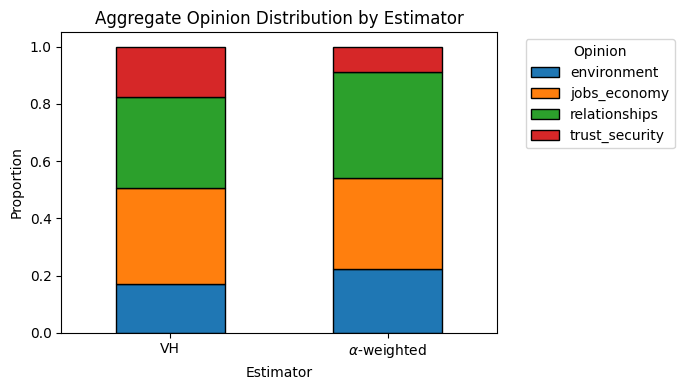

In [50]:
# --- Population-weighted aggregate distribution ---
neighborhood_weights = {
    "east":    0.26593033135,
    "west":    0.22175021240,
    "central": 0.26996601529,
    "quad":    0.24235344095,
}

def weighted_aggregate(dist, weights):
    """
    Compute population-weighted aggregate opinion distribution.
    dist: DataFrame indexed by neighborhood, columns are opinion categories
    weights: dict of {neighborhood: weight}
    Returns a Series of weighted proportions summing to 1.
    """
    w = pd.Series(weights)
    w = w / w.sum()  # normalize just in case
    # align weights to dist's index order
    w = w.reindex(dist.index)
    return dist.mul(w, axis=0).sum(axis=0)

agg_unweighted = weighted_aggregate(unweighted, neighborhood_weights)
agg_vh        = weighted_aggregate(vh_dist,    neighborhood_weights)
agg_weighted  = weighted_aggregate(weighted,   neighborhood_weights)

print("\nPopulation-weighted aggregate opinion distributions:")
print("\nUnweighted rows, pop-weighted aggregate:")
print(agg_unweighted.to_string())
print("\nVH-weighted rows, pop-weighted aggregate:")
print(agg_vh.to_string())
print("\nAlpha-weighted rows, pop-weighted aggregate:")
print(agg_weighted.to_string())

agg_combined = pd.DataFrame([agg_vh, agg_weighted], index=["VH", r"$\alpha$-weighted"])

fig, ax = plt.subplots(figsize=(7, 4))

agg_combined.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="black"
)

ax.set_title("Aggregate Opinion Distribution by Estimator")
ax.set_xlabel("Estimator")
ax.set_ylabel("Proportion")
ax.tick_params(axis='x', rotation=0)
ax.legend(title="Opinion", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("../img/vh_vs_alpha_neighborhood_true.pdf", bbox_inches="tight")
plt.show()

In [51]:
# Modularity per covariate, on the recruitment graph.
# Two null models:
#   ER null: expected within-group edges = (N_c / N)^2 * m
#   Newman:      expected within-group edges = d_c^2 / (4m)

# treat the recruitment graph as undirected for mod calcs
G_und = rds_G.to_undirected()
# drop any nodes that don't appear in survey_data (sentinels, "Seed", etc.)
for n in list(G_und.nodes()):
    if n not in set(survey_data["Name"]):
        G_und.remove_node(n)

modularity_covariates = [
    "Gender_long",
    "block",
    "Do you consider yourself international? ",
    "What political party do you most closely identify with?",
]

def covariate_partition(G, col):
    """Partition the nodes of G by their value of `col`. Drops nodes with NaN."""
    groups = defaultdict(set)
    for node in G.nodes():
        rows = survey_data.loc[survey_data["Name"] == node, col]
        if len(rows) and pd.notna(rows.values[0]):
            groups[rows.values[0]].add(node)
    return groups


results = []
for cov in modularity_covariates:
    groups = covariate_partition(G_und, cov)

    # restrict graph to nodes that actually have a value for this covariate
    covered = set().union(*groups.values()) if groups else set()
    H = G_und.subgraph(covered).copy()
    m = H.number_of_edges()
    N = H.number_of_nodes()

    if m == 0 or N == 0:
        results.append({
            "covariate": cov, "n_groups": len(groups),
            "Q_ER": float("nan"), "Q_Newman": float("nan"),
        })
        continue

    # ER null normalized by m so Q is on the standard scale
    Q_er = 0.0
    for nodes in groups.values():
        L_c = H.subgraph(nodes).number_of_edges()
        N_c = len(nodes)
        Q_er += L_c / m - (N_c / N) ** 2

    # Newman / configuration null (degree-preserving) — networkx built-in
    Q_new = nx.community.modularity(H, list(groups.values()))

    results.append({
        "covariate": cov, "n_groups": len(groups),
        "Q_ER": Q_er, "Q_Newman": Q_new,
    })

mod_df = pd.DataFrame(results).sort_values("Q_Newman", ascending=False)
print(mod_df.to_string(index=False))

                                              covariate  n_groups      Q_ER  Q_Newman
                                                  block         4  0.240862  0.229767
What political party do you most closely identify with?         4  0.120850  0.144033
               Do you consider yourself international?          2  0.027629  0.030178
                                            Gender_long         3 -0.074889 -0.054184
